# 2. Sensivity analysis

## 2.3 Test #3 for location origin perturbation

Model will be executed with *ANOTHER* 300 different version of the same input parameter, but there are a variation of origin location:

*Master input data:*
```yaml
   input:
    lat0: 40.5
    lon0: 10.5
    
```
The perturbated data in this test will be 300 different test into 0.15 deg of max variation

In [10]:
import yaml
import os
import random

def generate_random_coordinates(num_points, lat_range, lon_range):
    coordinates = []
    for _ in range(num_points):
        lat = random.uniform(*lat_range)
        lon = random.uniform(*lon_range)
        coordinates.append((lat, lon))
    return coordinates

# Generate 300 random coordinates within the specified ranges
coordinates = generate_random_coordinates(1, (40.5, 40.5), (10.5, 10.5))


# The base configuration structure
base_config = {
    'input': {
        'dataset_file_name': 'HECO_TEST.nc',
        'lat0': 40.5,
        'lon0': 10.5,
        'sim_diffusion_coeff': 10.0,
        'sim_duration_h': 72.0,
        'sim_particles': 100.0,
        'sim_timedelta_s': 3600.0,
        'spill_release_duration_h': 6.0,
        'time0': '2025-03-08 00:00:00',
        'volume_spilled_m3': 1000.0
    }
}

# Create a directory to store the generated YAML files
output_dir = "sa_2_3/input_yaml_files"
os.makedirs(output_dir, exist_ok=True)

# Generate and save the 10 versions
for i, (lat, lon) in enumerate(coordinates):
    # Update the coordinates for the current iteration
    base_config['input']['lat0'] = lat
    base_config['input']['lon0'] = lon
    
    # Define the output file name
    file_name = os.path.join(output_dir, f"sa_2_3_test_{i}.yaml")
    
    # Write the dictionary to a YAML file
    with open(file_name, 'w') as yaml_file:
        yaml.dump(base_config, yaml_file, default_flow_style=False, sort_keys=False)
        
    #print(f"Saved: {file_name} -> (lat0: {lat}, lon0: {lon})")

print("\nAll 300 YAML files have been generated successfully.")


All 300 YAML files have been generated successfully.


In [1]:
import yaml
import os
import random

def generate_random_coordinates(num_points, lat_range, lon_range):
    coordinates = []
    for _ in range(num_points):
        lat = random.uniform(*lat_range)
        lon = random.uniform(*lon_range)
        coordinates.append((lat, lon))
    return coordinates

# Generate 300 random coordinates within the specified ranges
coordinates = generate_random_coordinates(300, (40.44, 40.56), (10.44, 10.56))


# The base configuration structure
base_config = {
    'input': {
        'dataset_file_name': 'HECO_TEST.nc',
        'lat0': 40.5,
        'lon0': 10.5,
        'sim_diffusion_coeff': 10.0,
        'sim_duration_h': 72.0,
        'sim_particles': 100.0,
        'sim_timedelta_s': 3600.0,
        'spill_release_duration_h': 6.0,
        'time0': '2025-03-08 00:00:00',
        'volume_spilled_m3': 1000.0
    }
}

# Create a directory to store the generated YAML files
output_dir = "sa_2_3/input_yaml_files"
os.makedirs(output_dir, exist_ok=True)

# Generate and save the 10 versions
for i, (lat, lon) in enumerate(coordinates):
    # Update the coordinates for the current iteration
    base_config['input']['lat0'] = lat
    base_config['input']['lon0'] = lon
    
    # Define the output file name
    file_name = os.path.join(output_dir, f"sa_2_3_test_{i}.yaml")
    
    # Write the dictionary to a YAML file
    with open(file_name, 'w') as yaml_file:
        yaml.dump(base_config, yaml_file, default_flow_style=False, sort_keys=False)
        
    #print(f"Saved: {file_name} -> (lat0: {lat}, lon0: {lon})")

print("\nAll 300 YAML files have been generated successfully.")


All 300 YAML files have been generated successfully.


In [ ]:
import heco
import os
import geopandas as gpd
# Run 300 tests generated before
output_dir = "sa_2_3/heco_results"
os.makedirs(output_dir, exist_ok=True)
# input config files folder
for i in range(300):
    if i > 1: continue  # Skip all
    config_file = f"sa_2_3/input_yaml_files/sa_2_3_test_{i}.yaml"
    output = heco.run(config_file)
    
    # Save result to csv
    # output path
    csv_path = os.path.join(output_dir, f'heco_results_test_{i}.csv')
    output.to_csv(csv_path, index=False)

    # Save point to geojson with geopandas
    gdf = gpd.GeoDataFrame(output, geometry=gpd.points_from_xy(output.lon, output.lat))
    gdf.crs = "EPSG:4326"
    geojson_path = os.path.join(output_dir, f'heco_results_test_{i}.geojson')
    gdf.to_file(geojson_path, driver='GeoJSON')

    print(f'Simulation results for test {i} saved to {csv_path} and {geojson_path}')

    heco.create_points_animation(geojson_path, f'sa_2_3/heco_results_test_{i}.gif')
    heco.multitimestamp_plot(output, 6)
    # export webmap

    heco.create_webmap(
        HECOpoint_output_gdf_path = geojson_path,
        EMODnetLayers = True,
        settingsFile_path = config_file,
        output_path = f'{output_dir}/heco_map_test_{i}.html',
        savepolygons = True
    )


### 2.1.1 Results Comparison

In [12]:
import geopandas as gpd
import os

# create convex hull polygons for each test and compute metrics

def output_points_toconvexhull_polygons(gdf):
    ''' Function that converts points to convex hull polygons
    @param gdf: GeoDataFrame with the data to be converted
    @return: GeoDataFrame with the convex hull polygons
    '''
    gdf['time'] = gdf['time'].astype(str)
    points_time = gdf.dissolve(by='time', as_index=True)
    convex_hull = points_time.convex_hull
    return convex_hull

for i in range(300):
    # open GeoDataFrame
    gdf_path = f'sa_2_3/heco_results/heco_results_test_{i}.geojson'
    gdf = gpd.read_file(gdf_path) # must contain Points from HECO simulation

    # convert points to convex hull polygons
    convex_hull = output_points_toconvexhull_polygons(gdf)

    os.makedirs('sa_2_3/convex_hulls', exist_ok=True)

    # save file
    polygon_output_path = f'sa_2_3/convex_hulls/heco_results_test_{i}_polygons.geojson'
    convex_hull.to_file(polygon_output_path, driver='GeoJSON')




In [13]:


import polygons_score
import pandas as pd
import geopandas as gpd

# create table of metrics for each test
metrics_table = pd.DataFrame(columns=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE', 'origin_perturbation_km'])
obs_path = ('sa_2_3/convex_hulls/heco_results_test_0_polygons.geojson')
# load a gfeature from the observed data
obs_gdf = gpd.read_file(obs_path)

for i in range(300): # set properly the range of tests to analyze
    if i == 1: continue  # Skip the first test (test_id=1) as it is the observed data
    sim_path = (f'sa_2_3/convex_hulls/heco_results_test_{i}_polygons.geojson')
    # load the gfeature from simulated data
    sim_gdf = gpd.read_file(sim_path)
    # count the number of feature of the polygons in the observed and simulated files
    # obs_count = len(gpd.read_file(obs_path))
    obs_count = obs_gdf.shape[0]
    sim_count = sim_gdf.shape[0]
    #print(f'Test {i}: Observed features={obs_count}, Simulated features={sim_count}')
    # conduct file validation test: the number of feature are the same and >0 
    if obs_count > 0 and sim_count > 0 and obs_count == sim_count:
        # compute metrics for each feature
        
        for j in range(obs_count):
            obs_idx = j
            sim_idx = j
            # calculate area of observed and simulated polygons
            # obs_area = obs_gdf.iloc[obs_idx].geometry.area
            # sim_area = sim_gdf.iloc[sim_idx].geometry.area
           
            # print(f'Test {i}, Feature {j}: Observed Area={obs_area}, Simulated Area={sim_area}')
            metrics = polygons_score.compute_metrics(
                    obs_path,
                    sim_path,
                    obs_idx=obs_idx,
                    sim_idx=sim_idx,
                    projected_crs="EPSG:32632"
                )
            
            # add metrics data to the table
            metrics_table.loc[-1] = [i, j, metrics['SRA'], metrics['CI'], metrics['J'], metrics['DICE'], metrics['delta_x_km']]
            metrics_table.index = metrics_table.index + 1  # shifting index

# save metrics table to csv
metrics_table.to_csv(f'sa_2_3/heco_results_test_polygons_metrics.csv', index=False)

In [14]:
# calculate the distance of lon0,lat0 of each test from the master test (test 0) and add it to the metrics table
# convert latitude and langitude into UTM before calculating the distance

import math
import geopandas as gpd

master_test_path = 'sa_2_3/convex_hulls/heco_results_test_0_polygons.geojson'
master_test = gpd.read_file(master_test_path)
master_lon = master_test.iloc[0].geometry.centroid.x
master_lat = master_test.iloc[0].geometry.centroid.y
# convert lon,lat into UTM, x,y
master_utm = gpd.GeoSeries([gpd.points_from_xy([master_lon], [master_lat])[0]], crs="EPSG:4326").to_crs("EPSG:32636")
master_x = master_utm.x[0]
master_y = master_utm.y[0]

for i in range(300):
    test_path = f'sa_2_3/convex_hulls/heco_results_test_{i}_polygons.geojson'
    test = gpd.read_file(test_path)
    test_lon = test.iloc[0].geometry.centroid.x
    test_lat = test.iloc[0].geometry.centroid.y
    # convert lon,lat into UTM, x,y
    test_utm = gpd.GeoSeries([gpd.points_from_xy([test_lon], [test_lat])[0]], crs="EPSG:4326").to_crs("EPSG:32636")
    test_x = test_utm.x[0]
    test_y = test_utm.y[0]
    
    distance = math.hypot(test_x - master_x, test_y - master_y)
    metrics_table.loc[metrics_table['test_id'] == i, 'origin_perturbation'] = distance


metrics_table.to_csv(f'sa_2_3/heco_results_test_polygons_metrics.csv', index=False)

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# import csv file into pandas dataframe
metrics_table = pd.read_csv('sa_2_3/heco_results_test_polygons_metrics.csv')
os.makedirs('sa_2_3/plots', exist_ok=True)

# Keep only rows with a usable test id and a perturbation value
metrics_table = metrics_table.dropna(subset=['test_id', 'origin_perturbation']).copy()
metrics_table['test_id'] = metrics_table['test_id'].astype(int)

# Plot one figure per test that actually has metric rows
for i in sorted(metrics_table['test_id'].unique()):
    if i == 0:
        continue  # skip the master test

    subset = metrics_table[metrics_table['test_id'] == i].copy()
    if subset.empty:
        print(f'Skipping test {i}: no metric rows found.')
        continue

    subset = subset.sort_values(by='sim_step')
    perturbation_distance = subset['origin_perturbation'].iloc[0]

    plt.figure(figsize=(10, 6))
    plt.title(f'Metrics vs LPDM Iterations for Test {i}: Perturbation distance={perturbation_distance:.0f} m')
    plt.xlabel('LPDM iterations')
    plt.ylabel('Metric value')
    plt.plot(subset['sim_step'], subset['SRA'], label='Success Rate Area (SRA)')
    plt.plot(subset['sim_step'], subset['CI'], label='Centroid Index (CI)')
    plt.plot(subset['sim_step'], subset['Jaccard'], label='Jaccard Similarity Index')
    plt.plot(subset['sim_step'], subset['DICE'], label='Dice Similarity Coefficient (DSC)')
    plt.legend()
    plt.ylim(0, 1)
    plt.grid()
    plt.savefig(f'sa_2_3/plots/metrics_vs_lpdm_iterations_test_{i}.png')
    plt.close()


In [16]:
import pandas as pd


def print_report(m: dict) -> None:
    SEP = '─' * 80
    print(SEP)
    print(f"  Test ID: {m['test_id']}, LPDM iteration: {m['sim_step']}, Perturbation distance: {m['origin_perturbation']:.0f} m")
    print(SEP)
    print(f"  Success Rate Area      (SRA) : {m['SRA']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Centroid Index          (CI) : {m['CI']:>10.4f}   [≥ 0,  lower  ↓ = better]")
    print(f"  Jaccard Similarity Index (J) : {m['Jaccard']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Dice Similarity Coeff. (DSC) : {m['DICE']:>10.4f}   [0–1,  higher ↑ = better]")
    print(SEP)

# import csv file into pandas dataframe
metrics_table = pd.read_csv('sa_2_3/heco_results_test_polygons_metrics.csv')
metrics_table = metrics_table.dropna(subset=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE', 'origin_perturbation']).copy()
metrics_table['test_id'] = metrics_table['test_id'].astype(int)
metrics_table['sim_step'] = metrics_table['sim_step'].astype(int)

# sort by perturbation distance
metrics_table = metrics_table.sort_values(by=['origin_perturbation'], ascending=[True])

# create dataframe with the last iteration metrics for each test_id
metrics_last_iteration = []

for test_id in sorted(metrics_table['test_id'].unique()):
    if test_id == 0:
        continue

    metrics_subset = metrics_table[metrics_table['test_id'] == test_id]
    if metrics_subset.empty:
        continue

    sim_step_max = int(metrics_subset['sim_step'].max())
    metric_to_print = metrics_subset[metrics_subset['sim_step'] == sim_step_max].iloc[0].to_dict()
    metrics_last_iteration.append({
        'test_id': metric_to_print['test_id'],
        'sim_step': metric_to_print['sim_step'],
        'SRA': metric_to_print['SRA'],
        'CI': metric_to_print['CI'],
        'Jaccard': metric_to_print['Jaccard'],
        'DICE': metric_to_print['DICE'],
        'origin_perturbation': metric_to_print['origin_perturbation'],
    })

metrics_last_iteration = pd.DataFrame(metrics_last_iteration)
metrics_last_iteration.to_csv('sa_2_3/heco_results_test_polygons_metrics_last_iteration.csv', index=False)


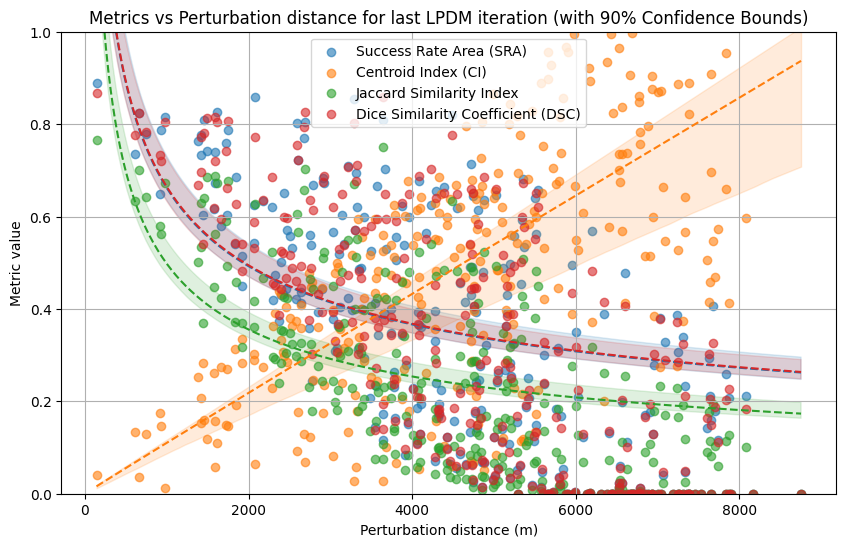

In [17]:
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics_last_iteration = pd.read_csv('sa_2_3/heco_results_test_polygons_metrics_last_iteration.csv')

def power_law(x, a, b):
    return a * (x ** b)

# plot diagrams of metrics_last_iteration
#sort by perturbation distance
metrics_last_iteration = metrics_last_iteration.sort_values(by=['origin_perturbation'], ascending=[True])

plt.figure(figsize=(10, 6))
plt.title('Metrics vs Perturbation distance for last LPDM iteration (with 90% Confidence Bounds)')
plt.xlabel('Perturbation distance (m)')
plt.ylabel('Metric value')

variables = [
    ('SRA', 'Success Rate Area (SRA)', 'tab:blue'),
    ('CI', 'Centroid Index (CI)', 'tab:orange'),
    ('Jaccard', 'Jaccard Similarity Index', 'tab:green'),
    ('DICE', 'Dice Similarity Coefficient (DSC)', 'tab:red')
]

x_data = metrics_last_iteration['origin_perturbation'].values
# avoid zero for power law
x_fit = np.linspace(max(0.1, x_data.min()), x_data.max(), 300)

for var, label, color in variables:
    y_data = metrics_last_iteration[var].values
    plt.scatter(x_data, y_data, label=label, color=color, alpha=0.6)
    
    # Fit power law trendline
    try:
        mask = (x_data > 0) & (y_data > 0)
        if np.sum(mask) > 2:
            popt, pcov = curve_fit(power_law, x_data[mask], y_data[mask], maxfev=10000)
            plt.plot(x_fit, power_law(x_fit, *popt), color=color, linestyle='--')
            
            # Calculate 90% confidence bounds using Monte Carlo sampling
            samples = np.random.multivariate_normal(popt, pcov, 1000)
            y_fits = np.array([power_law(x_fit, *s) for s in samples])
            lower_bound = np.percentile(y_fits, 30, axis=0)
            upper_bound = np.percentile(y_fits, 99.95, axis=0)
            plt.fill_between(x_fit, lower_bound, upper_bound, color=color, alpha=0.15)
    except Exception as e:
        print(f'Could not fit trendline for {var}: {e}')

plt.legend()
plt.ylim(0, 1)
plt.grid()
plt.savefig('sa_2_3/metrics_vs_origin_perturbation_last_iteration_bounds.png')
plt.show()
